In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import re
import string

In [2]:
data_fake=pd.read_csv('E:\\Internship\\Fake_news_detection\\Fake.csv')
data_true=pd.read_csv('E:\\Internship\\Fake_news_detection\\True.csv')

In [3]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
data_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
data_fake["class"]=0
data_true["class"]=1

In [6]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [7]:
data_fake_manual_testing=data_fake.tail(10)
for i in range(23480,23470,-1):
    data_fake.drop([i],axis=0,inplace=True)
data_true_manual_testing=data_true.tail(10)
for i in range(21416,21406,-1):
    data_true.drop([i],axis=0,inplace=True)

In [8]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [9]:
data_fake_manual_testing["class"]=0
data_true_manual_testing["class"]=1

C:\Users\majee\AppData\Local\Temp\ipykernel_24124\1040235159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fake_manual_testing["class"]=0
C:\Users\majee\AppData\Local\Temp\ipykernel_24124\1040235159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_true_manual_testing["class"]=1


In [10]:
data_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [11]:
data_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [12]:
data_merge=pd.concat([data_fake,data_true],axis=0)
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [13]:
data_merge.tail(10)

,title,text,subject,date,class
21397,Germany's Schulz says he would demand U.S. wit...,BERLIN (Reuters) - The leader of Germany s Soc...,worldnews,"August 23, 2017",1
21398,Blunt instrument? What a list of banned articl...,SHANGHAI (Reuters) - An old review of an acade...,worldnews,"August 23, 2017",1
21399,Saudi police release teenager detained for dan...,DUBAI (Reuters) - A 14-year-old boy who was de...,worldnews,"August 22, 2017",1
21400,"The People's Princess, Britons work to keep me...",LONDON (Reuters) - Abdul Daoud spilt most of t...,worldnews,"August 23, 2017",1
21401,"Argentina labor unions protest job losses, Mac...",BUENOS AIRES (Reuters) - Argentina s main labo...,worldnews,"August 22, 2017",1
21402,Exclusive: Trump's Afghan decision may increas...,ON BOARD A U.S. MILITARY AIRCRAFT (Reuters) - ...,worldnews,"August 22, 2017",1
21403,U.S. puts more pressure on Pakistan to help wi...,WASHINGTON (Reuters) - The United States sugge...,worldnews,"August 21, 2017",1
21404,Exclusive: U.S. to withhold up to $290 million...,WASHINGTON (Reuters) - The United States has d...,worldnews,"August 22, 2017",1
21405,Trump talks tough on Pakistan's 'terrorist' ha...,ISLAMABAD (Reuters) - Outlining a new strategy...,worldnews,"August 22, 2017",1
21406,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1


In [14]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [15]:
data = data_merge.drop(['title', 'subject', 'date'],axis=1)

In [16]:
data.columns

Index(['text', 'class'], dtype='object')

In [17]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [18]:
data = data.sample(frac=1)

In [19]:
data.head()

,text,class
5095,Donald Trump has been facing a furious backlas...,0
11705,NEW YORK (Reuters) - Lawyers for an executive ...,1
5051,"Greetings patriots, right-wing activist and ...",0
22286,21st Century Wire says The Washington Post has...,0
5012,If you ve never had to suffer through any of T...,0


In [20]:
data.reset_index(inplace=True)
data.drop(['index'],axis=1,inplace=True)

In [21]:
data.columns

Index(['text', 'class'], dtype='object')

In [22]:
data.head()

,text,class
0,Donald Trump has been facing a furious backlas...,0
1,NEW YORK (Reuters) - Lawyers for an executive ...,1
2,"Greetings patriots, right-wing activist and ...",0
3,21st Century Wire says The Washington Post has...,0
4,If you ve never had to suffer through any of T...,0


In [23]:
def wordopt(text):
    text = re.sub(r'\W', ' ', text)
    return text

In [24]:
data['text']=data['text'].apply(wordopt)

In [25]:
data.head()

,text,class
0,Donald Trump has been facing a furious backlas...,0
1,NEW YORK Reuters Lawyers for an executive ...,1
2,Greetings patriots right wing activist and ...,0
3,21st Century Wire says The Washington Post has...,0
4,If you ve never had to suffer through any of T...,0


In [26]:
x=data['text']
y=data['class']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

xv_train = vectorizer.fit_transform(x_train)
xv_test = vectorizer.transform(x_test)

In [29]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)
LR.fit(xv_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
pred_lr=LR.predict(xv_test)

In [31]:
LR.score(xv_test,y_test)

0.9866310160427807

In [32]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5806
           1       0.98      0.99      0.99      5414

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xv_train, y_train)

KNeighborsClassifier()

In [34]:
knn_pred = knn.predict(xv_test)

In [35]:
knn.score(xv_test,y_test)

0.7600713012477719

In [36]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.70      0.94      0.80      5806
           1       0.89      0.57      0.70      5414

    accuracy                           0.76     11220
   macro avg       0.80      0.75      0.75     11220
weighted avg       0.79      0.76      0.75     11220



In [37]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(xv_train, y_train)

RandomForestClassifier()

In [38]:
rf_pred = rf.predict(xv_test)

In [39]:
rf.score(xv_test,y_test)

0.9977718360071302

In [40]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5806
           1       1.00      1.00      1.00      5414

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



In [41]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
mlp.fit(xv_train, y_train)

MLPClassifier(max_iter=300)

In [42]:
mlp_pred = mlp.predict(xv_test)

In [43]:
mlp.score(xv_test,y_test)

0.9918894830659537

In [44]:
print(classification_report(y_test,mlp_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5806
           1       0.99      0.99      0.99      5414

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



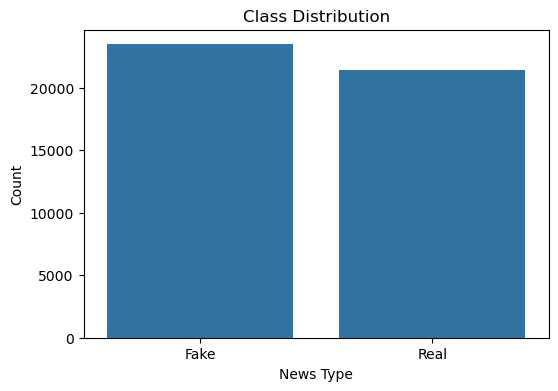

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data)
plt.xticks([0,1], ['Fake', 'Real'])
plt.title('Class Distribution')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

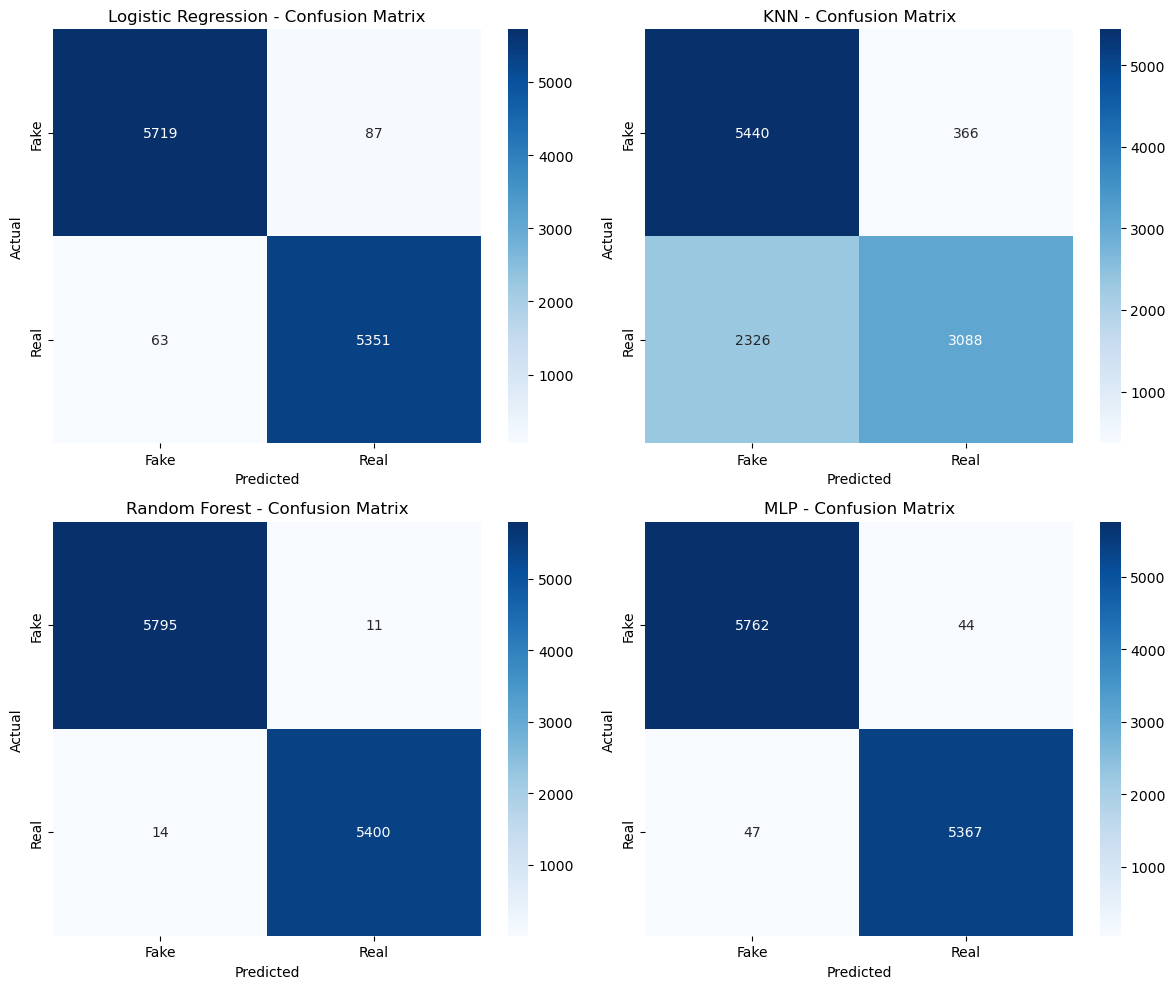

In [46]:
models_preds = {
    'Logistic Regression': pred_lr,
    'KNN': knn_pred,
    'Random Forest': rf_pred,
    'MLP': mlp_pred
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, preds) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

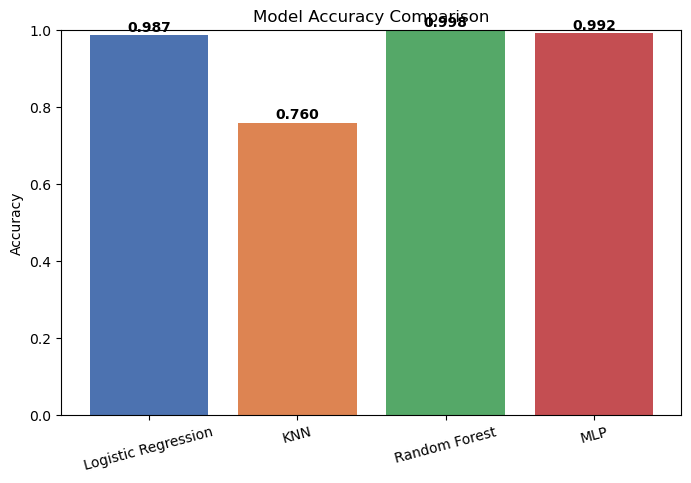

In [47]:
accuracies = {
    'Logistic Regression': accuracy_score(y_test, pred_lr),
    'KNN': accuracy_score(y_test, knn_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'MLP': accuracy_score(y_test, mlp_pred)
}

plt.figure(figsize=(8,5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.show()


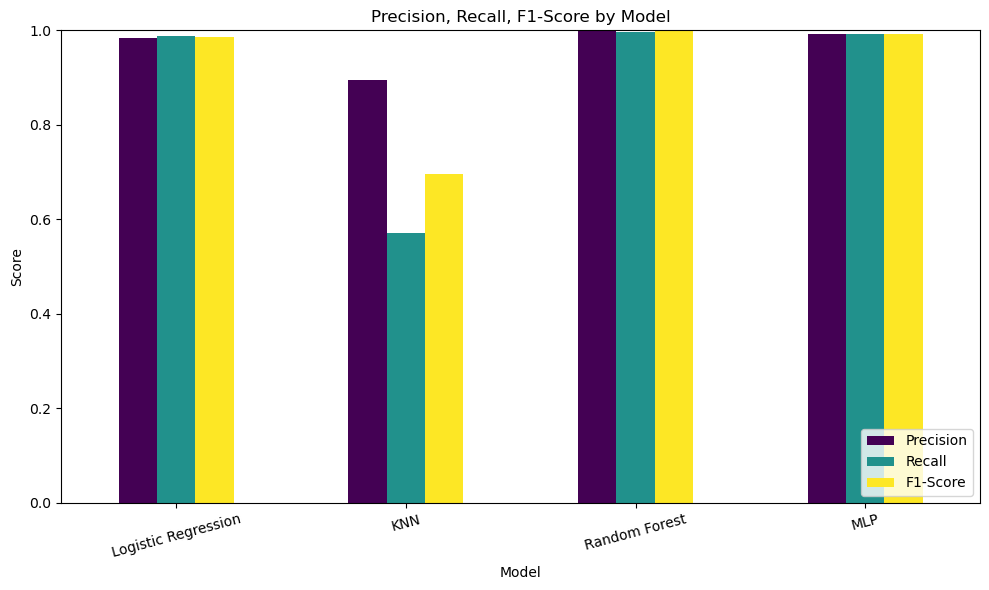

In [48]:
metrics_data = []
for name, preds in models_preds.items():
    metrics_data.append({
        'Model': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Model')

metrics_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Precision, Recall, F1-Score by Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

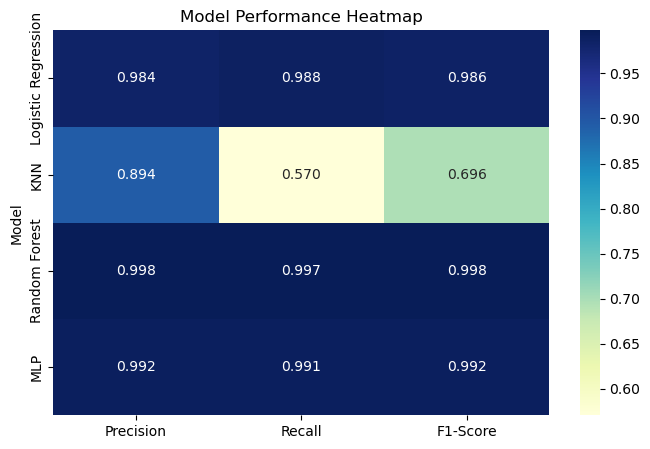

In [49]:
plt.figure(figsize=(8,5))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Model Performance Heatmap')
plt.show()

In [50]:
def output_lable(n):
    if n == 0:
        return "Fake news"
    elif n == 1:
        return "True news"


def manual_testing(news):
    testing_news = {"text": [news]}
    new_def_test = pd.DataFrame(testing_news)

    new_def_test["text"] = new_def_test["text"].apply(wordopt)

    new_x_test = new_def_test["text"]
    new_xv_test = vectorizer.transform(new_x_test)

    pred_lr = LR.predict(new_xv_test)
    knn_pred = knn.predict(new_xv_test)
    rf_pred = rf.predict(new_xv_test)
    mlp_pred = mlp.predict(new_xv_test)

    return print(
        "\n\nKNN Prediction: {}\nLR Prediction: {}\nRF Prediction: {}\nMLP Prediction: {}".format(
            output_lable(knn_pred[0]),
            output_lable(pred_lr[0]),
            output_lable(rf_pred[0]),
            output_lable(mlp_pred[0])
        )
    )

In [52]:
news = str(input())
manual_testing(news)

 NEW YORK (Reuters) - A federal judge in New York on Thursday threw out a lawsuit that had accused President Donald Trump of violating the U.S. Constitution by accepting foreign payments through his hotels and other businesses, handing him a major victory on an issue that has dogged him since even before he took office in January. Though other lawsuits remain pending that make similar claims, the ruling by U.S. District Judge George Daniels is the first to weigh the merits of the U.S. Constitutionâ€™s anti-corruption provisions as they apply to Trump, a wealthy businessman who as president regularly visits his own hotels, resorts and golf clubs. In a 29-page opinion granting the Trump administrationâ€™s request to toss the suit, Daniels said the plaintiffs did not have legal standing to bring the suit. The plaintiffs included the nonprofit watchdog group Citizens for Responsibility and Ethics in Washington (CREW), a hotel owner, a hotel events booker and a restaurant trade group. The l



KNN Prediction: True news
LR Prediction: True news
RF Prediction: True news
MLP Prediction: True news
